## International RSE survey 2026

Import needed packages

In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from wordcloud import WordCloud
import textwrap

Some functions to read the data

In [94]:
def plot_barplot_percentage(df, col, colsdf, save=False):
    '''
    Function to plot barplot with percentage of respondents giving each answer.

    Parameters
    ----------
    df : DataFrame
        The main data Data Frame.
    col : str
        A string name of the column with the question we want to plot.
    colsdf : DataFrame
        Data Frame containing question text.
    save : bool, optional
        A flag to say whether you want to save the produced plot. Check the
        function to see if the path and name are correct. The default is False.

    Returns
    -------
    int
        DESCRIPTION.

    '''
    #calculate percentages
    pct = (
        df[col]
        .value_counts(normalize=True) * 100)
    
    #reset index
    pct_df = pct.reset_index()
    pct_df.columns = [col, "percent"]
    
    # create new figure of size 10 (width) by 7 (height)
    plt.figure(figsize=(10,7))
    g=sns.barplot(data=pct_df, x = 'percent', y = col)
    
    # add labels with percentage values
    for container in g.containers:
        g.bar_label(container, fmt="%.1f%%")
    
    # add title with the question text
    title = colsdf.loc[colsdf['New_name'].str.startswith(col), 'Question'].iloc[0]
    if 'AI5'in col:
        title = re.sub(r"\[(.*?)\]", r"\1", title).strip()
        
    else:
        title = re.sub(r"\[.*?\]", "", title).strip()
    
    n = df[col].notna().sum()
    plt.title(textwrap.fill(f"{title}\n(n={n})", width=60))
    
    #save the figure
    if save:
        img_path = '../img/'
        plt.savefig(img_path+col+'_barplot_perc.png')#, bbox_inches="tight")
    plt.show()
    return 0

In [95]:
def plot_barplot(df, col, colsdf, save=False):
    '''
    Function to plot barplot with percentage of respondents giving each answer.

    Parameters
    ----------
    df : DataFrame
        The main data Data Frame.
    col : str
        A string name of the column with the question we want to plot.
    colsdf : DataFrame
        Data Frame containing question text.
    save : bool, optional
        A flag to say whether you want to save the produced plot. Check the
        function to see if the path and name are correct. The default is False.

    Returns
    -------
    int
        DESCRIPTION.

    '''
 
    
    
    # create new figure of size 10 (width) by 7 (height)
    plt.figure(figsize=(10,7))
    g=sns.barplot(data=df, x = 'number', y = col)
    
    # add labels with percentage values
    for container in g.containers:
        g.bar_label(container, fmt="%.1f%%")
    
    # add title with the question text
    title = colsdf.loc[colsdf['New_name'].str.startswith(col), 'Question'].iloc[0]
    if 'AI5'in col:
        title = re.sub(r"\[(.*?)\]", r"\1", title).strip()
        
    else:
        title = re.sub(r"\[.*?\]", "", title).strip()
    
    n = df[col].notna().sum()
    plt.title(textwrap.fill(f"{title}\n(n={n})", width=60))
    
    #save the figure
    if save:
        img_path = '../img/'
        plt.savefig(img_path+col+'_barplot.png')#, bbox_inches="tight")
    plt.show()
    return 0

In [96]:
def tell_me_more(colname, cols, df):

    title = cols.loc[cols['New_name'].str.startswith(colname), 'Question'].iloc[0]
    print(title)
    print(df[colname])

In [97]:
def tell_me_more_count(colname, cols, df):

    title = cols.loc[cols['New_name'].str.startswith(colname), 'Question'].iloc[0]

    data = df[colname].dropna()
    print(f"Total responses: {len(data)}")

    print(title)
    print(df[colname].value_counts())

In [98]:

def wordcloud(colname, cols, df):
    title = cols.loc[cols['New_name'].str.startswith(colname), 'Question'].iloc[0]

    n = df[colname].notna().sum()

    
    freq = df[colname].dropna().str.lower().value_counts().to_dict()
    
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"{title}\n(n={n})")

    plt.show()


In [99]:
def wordcloud_words(colname, cols, df):
    title = cols.loc[cols['New_name'].str.startswith(colname), 'Question'].iloc[0]

    n = df[colname].notna().sum()

    
    # Join all non-null values into one text string
    text = ' '.join(df[colname].dropna().astype(str).str.lower())
    
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"{title}\n(n={n})")

    plt.show()

In [100]:
def plot_multiselect(prefix, cols, df):
    matching = cols[cols['New_name'].str.startswith(prefix)]
    
    #to get only full number of people who ticked at least one
    matching_cols = [c for c in df.columns if c.startswith(prefix) and 'other' not in c]
    n = df[matching_cols].any(axis=1).sum()

    #n = len(df_nord)
    counts = []
    labels = []
    for _, row in matching.iterrows():
        colname = row['New_name']
        if colname in df.columns:
            if 'other' in colname:
                counts.append(df[colname].notna().sum() / n * 100)
                labels.append('Other')
            else:
                counts.append(df[colname].sum() / n * 100)
                match = re.search(r'\[(.*?)\]', row['Question'])
                labels.append(match.group(1) if match else colname)
    
    result_df = pd.DataFrame({'label': labels, 'percent': counts}).sort_values('percent')
    
    title = re.sub(r'\[.*?\]', '', matching.iloc[0]['Question']).strip()
    title= f"{title}\n(n={n})"
    
    plt.figure(figsize=(10, 7))
    g = sns.barplot(data=result_df, x='percent', y='label')
    for container in g.containers:
        g.bar_label(container, fmt='%.1f%%')
    plt.xlabel('Percentage of respondents')
    plt.xlim(0, 100)
    plt.title(textwrap.fill(title, width=60))
    #plt.title(f"{title}\n(n={n})")

    plt.tight_layout()
    #if save:
    #    plt.savefig(img_path + prefix + '_multiselect.png')
    plt.show()

Prepare data

In [101]:
#Input path
file_path = './RSE_survey_2026_data/'

#Output path
img_path = './img/'

# load data file
df = pd.read_csv(file_path+'2026_tf.csv', low_memory=False)
# load column names and question texts
cols = pd.read_csv(file_path+'2026_cols.csv')

Example plots

In [102]:
# plot the first genAI question
#plot_barplot_percentage(df, 'genAI1_0', cols)

# plot country question
#plot_barplot_percentage(df, 'socio1_0', cols)

Extract Nordics by country

In [103]:
df_fi = df[df['socio1_0']=='Finland'] 
df_no = df[df['socio1_0']=='Norway']
df_se = df[df['socio1_0']=='Sweden'] 
df_dk = df[df['socio1_0']=='Denmark'] 
df_is = df[df['socio1_0']=='Iceland']
df_ee = df[df['socio1_0']=='Estonia'] 

#df_nord = 

In [104]:

df_nord = pd.concat([df_fi, df_se, df_dk, df_no, df_is, df_ee])

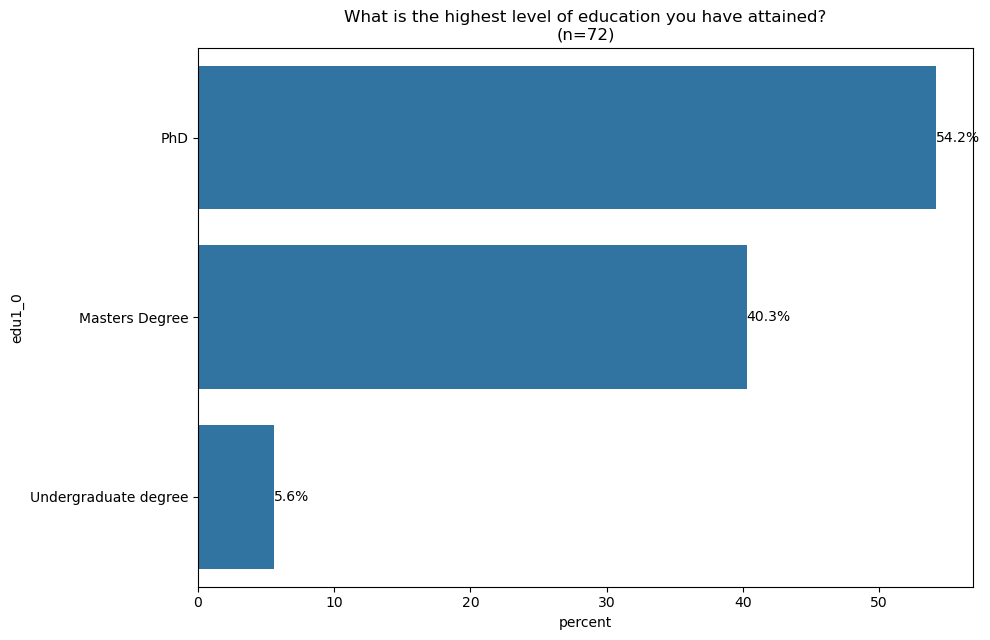

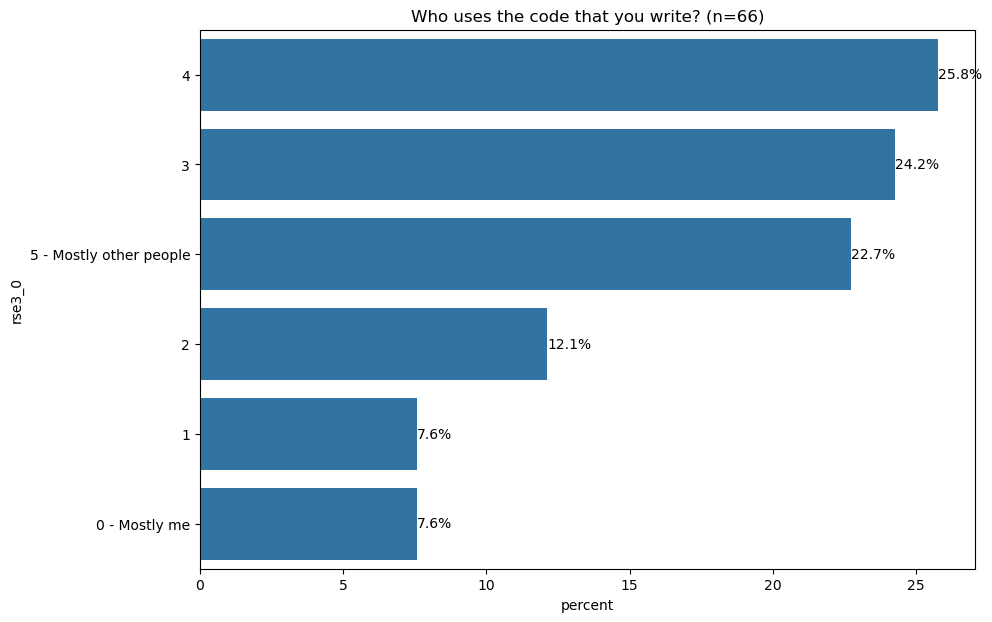

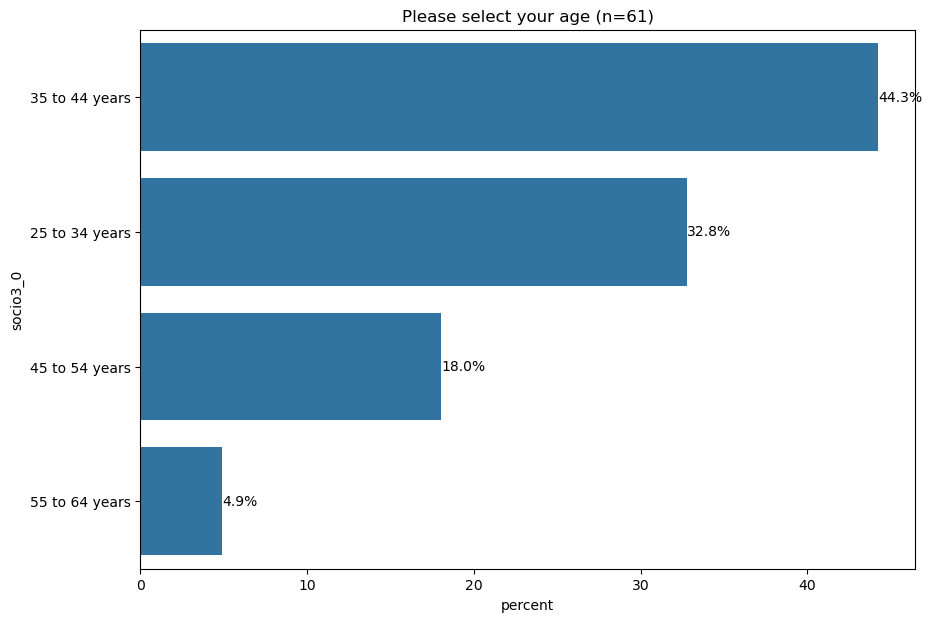

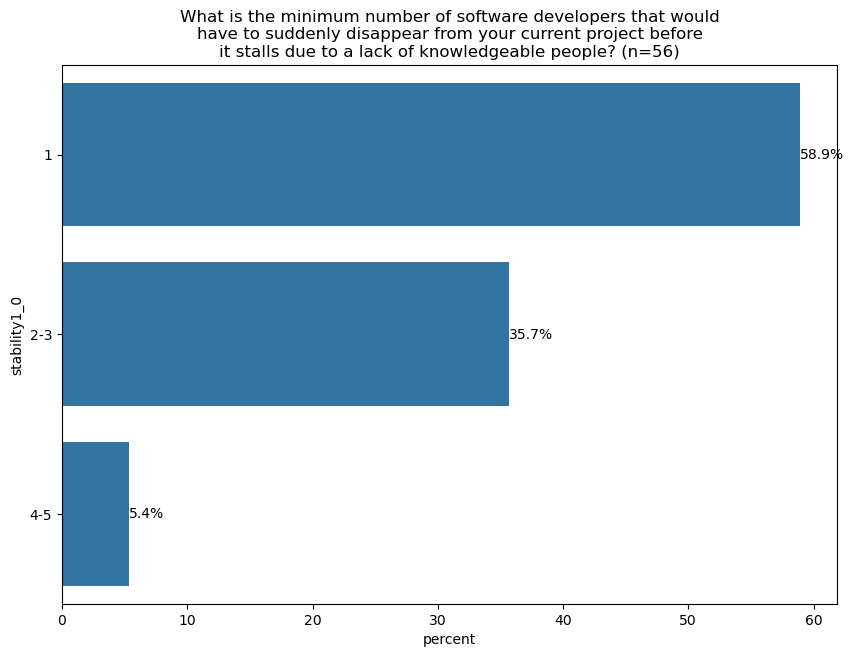

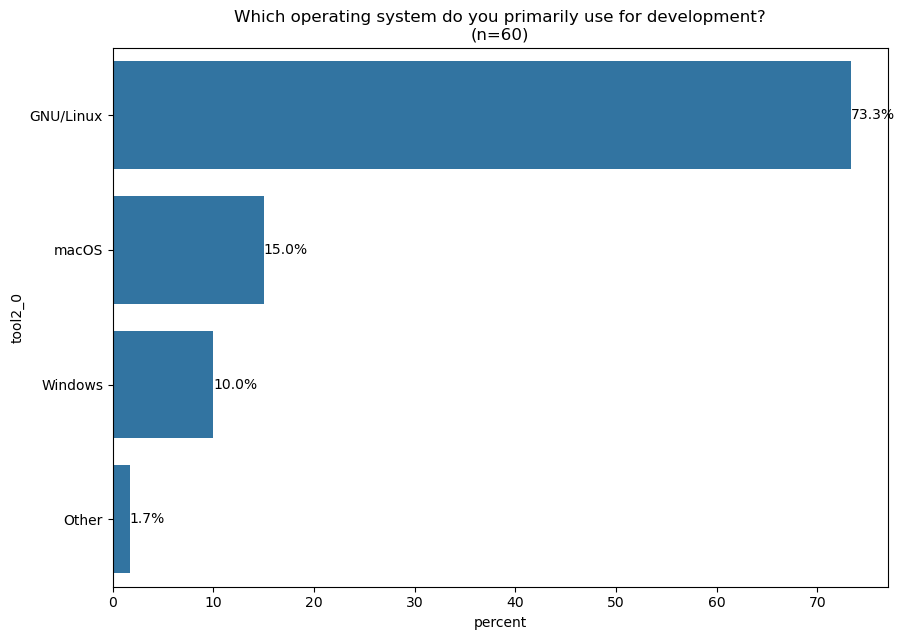

0

In [105]:
plot_barplot_percentage(df_nord, 'edu1_0', cols)
#plot_barplot_percentage(df_nord, 'rse1_0', cols)
plot_barplot_percentage(df_nord, 'rse3_0', cols)
plot_barplot_percentage(df_nord, 'socio3_0', cols)
plot_barplot_percentage(df_nord, 'stability1_0', cols)
#plot_barplot_percentage(df_nord, 'stability2_0', cols)
plot_barplot_percentage(df_nord, 'tool2_0', cols)


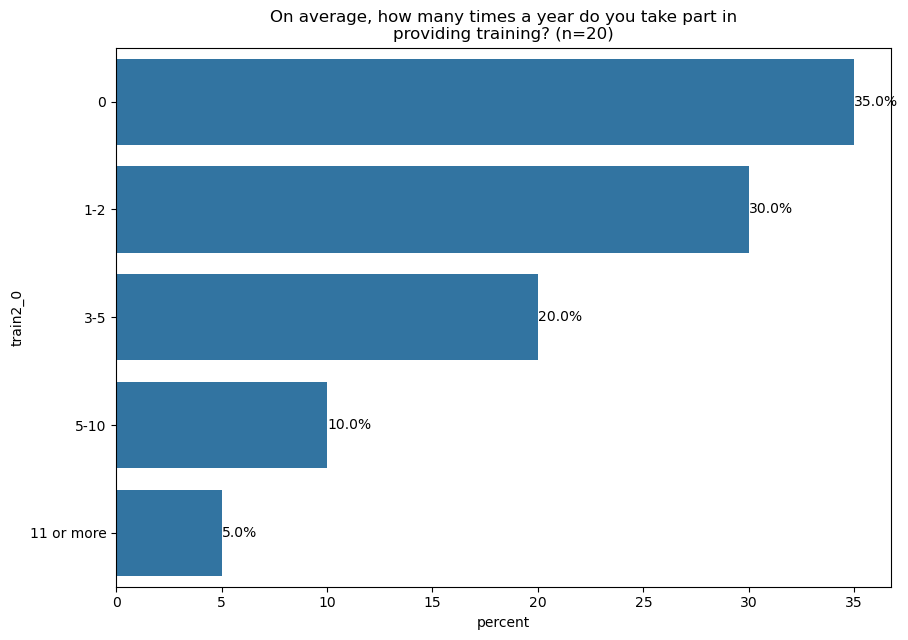

0

In [106]:
plot_barplot_percentage(df_fi, 'train2_0', cols)


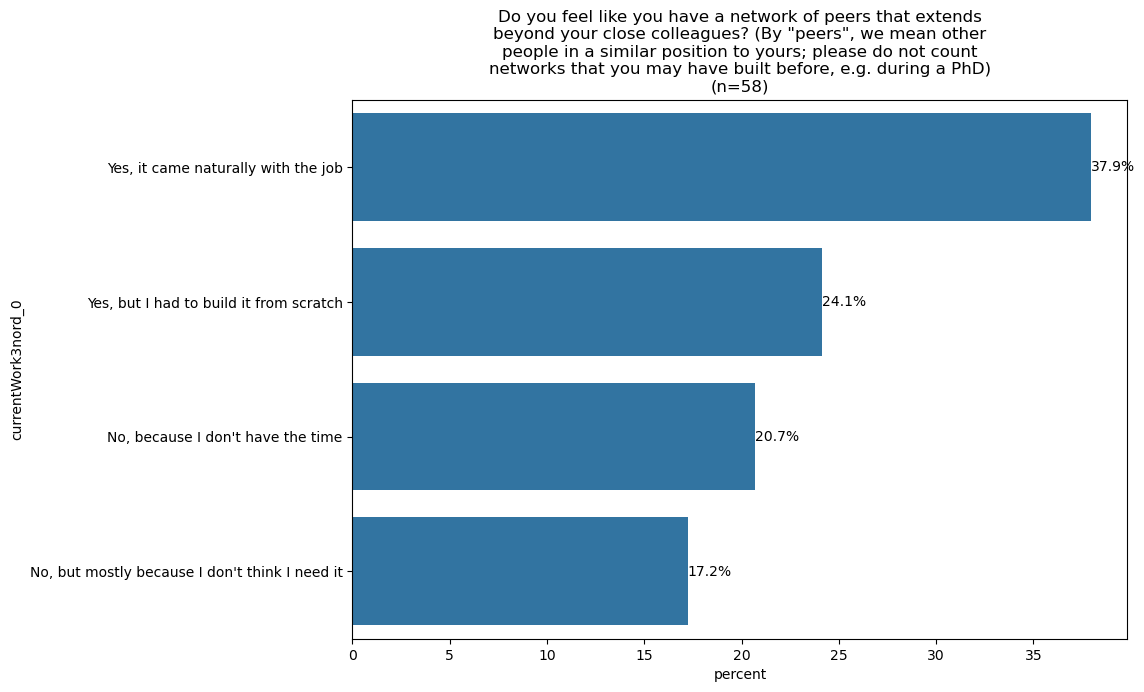

0

In [107]:
#plot_barplot_percentage(df_fi, 'currentWork3nord_0', cols)
#plot_barplot_percentage(df_se, 'currentWork3nord_0', cols)
#plot_barplot_percentage(df_no, 'currentWork3nord_0', cols)
#plot_barplot_percentage(df_is, 'currentWork3nord_0', cols)
#plot_barplot_percentage(df_dk, 'currentWork3nord_0', cols)
#plot_barplot_percentage(df_ee, 'currentWork3nord_0', cols)
plot_barplot_percentage(df_nord, 'currentWork3nord_0', cols)

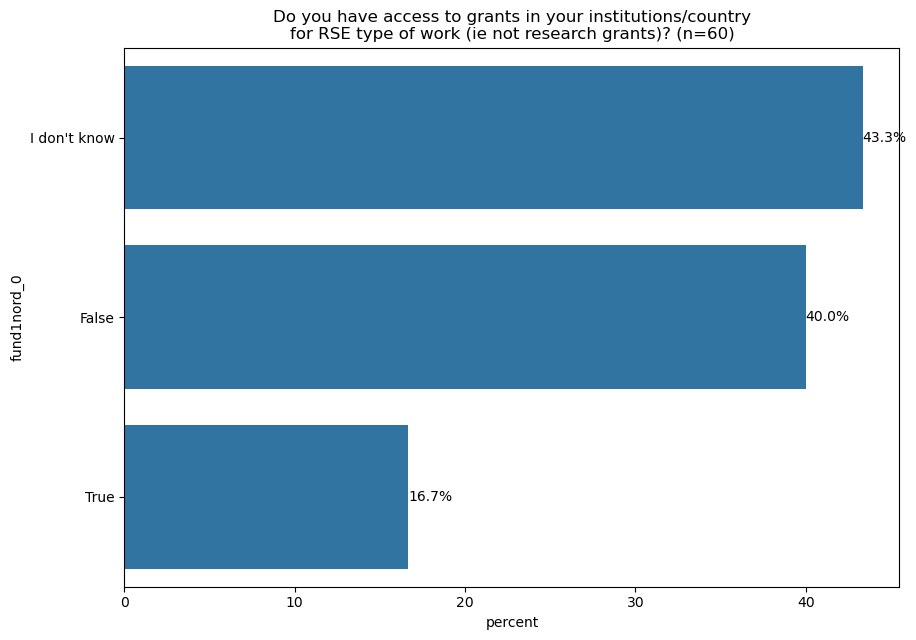

0

In [108]:

plot_barplot_percentage(df_nord, 'fund1nord_0', cols)

In [109]:
tell_me_more_count('currentEmp5_0', cols, df_nord)

Total responses: 60
 What is your official job title?
currentEmp5_0
Research engineer                                  7
Postdoctoral researcher                            5
RSE                                                3
Research Engineer                                  3
Doctoral researcher                                2
Research Software Engineer                         2
Researcher                                         2
Senior Engineer                                    2
Senior engineer                                    2
Senioringeniør                                     2
academic RSE                                       1
Machine Learning Specialist                        1
Senior scientist                                   1
Application Specialist                             1
Research Fellow                                    1
Research Software Enigneer                         1
Doctoral Candidate                                 1
research engineer              

In [110]:
tell_me_more_count('currentEmp12_0', cols, df_nord)

Total responses: 67
 Do you work full time or part time?
currentEmp12_0
Full Time    63
Part-time     4
Name: count, dtype: int64


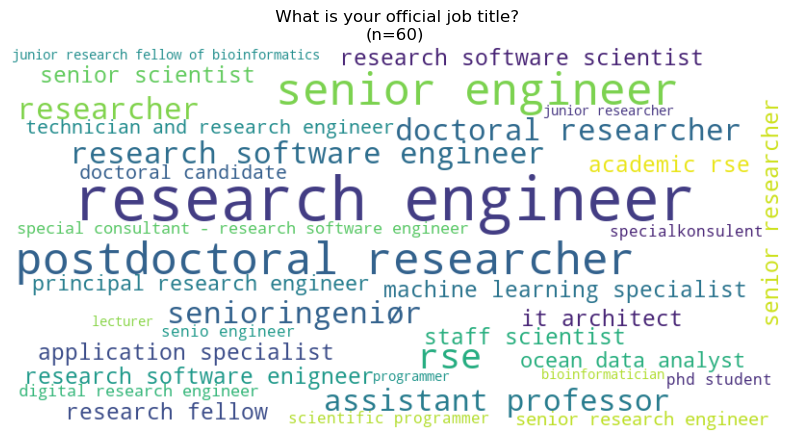

In [111]:
wordcloud('currentEmp5_0', cols, df_nord)

In [112]:
tell_me_more_count('currentEmp10_0', cols, df_nord)

Total responses: 67
 What is the nature of your current employment?
currentEmp10_0
Permanent                   46
Fixed-term                  18
Prefer not to say            1
Other                        1
Zero-hours/hourly/casual     1
Name: count, dtype: int64


In [113]:
tell_me_more_count('fund1nord_0', cols, df_nord)

Total responses: 60
 Do you have access to grants in your institutions/country for RSE type of work (ie not research grants)?
fund1nord_0
I don't know    26
False           24
True            10
Name: count, dtype: int64


In [114]:
tell_me_more_count('turnOver3[SQ001]_0', cols, df_nord)

Total responses: 66
 How likely are you to choose to leave your job in the next 12 months? []
turnOver3[SQ001]_0
Very unlikely                 31
Neither likely or unlikely    15
Unlikely                      15
Very likely                    3
Likely                         2
Name: count, dtype: int64


In [115]:
tell_me_more_count('stability2_0', cols, df_nord)

Total responses: 59
 Do the projects you work on typically have a plan to cope with developers leaving the group?
stability2_0
False    49
True     10
Name: count, dtype: int64


In [116]:
tell_me_more_count('likert4b[1]_0', cols, df_nord)

Total responses: 63
 I feel that my contribution to research is recognised by... [my institution.]
likert4b[1]_0
Agree                        37
Neither agree or disagree    15
Disagree                      9
Strongly disagree             2
Name: count, dtype: int64


In [117]:
tell_me_more_count('likert4b[2]_0', cols, df_nord)

Total responses: 63
 I feel that my contribution to research is recognised by... [ my supervisor/line manager.]
likert4b[2]_0
Agree                        50
Neither agree or disagree     9
Disagree                      3
Strongly disagree             1
Name: count, dtype: int64


In [118]:
tell_me_more_count('likert5a[1]_0', cols, df_nord)

Total responses: 64
  [It would not be very difficult for me to get an equivalent job in a different institution]
likert5a[1]_0
Agree                        20
Neither agree or disagree    18
Disagree                     12
Strongly disagree             8
Strongly Agree                6
Name: count, dtype: int64


In [119]:
tell_me_more_count('likert5a[2]_0', cols, df_nord)

Total responses: 62
  [It is likely that I will gain a promotion within my current group ]
likert5a[2]_0
Neither agree or disagree    21
Disagree                     17
Strongly disagree            12
Agree                        11
Strongly Agree                1
Name: count, dtype: int64


In [120]:
tell_me_more_count('likert5a[3]_0', cols, df_nord)

Total responses: 61
  [There are many opportunities within my chosen career plan]
likert5a[3]_0
Neither agree or disagree    18
Disagree                     14
Agree                        12
Strongly disagree             9
Strongly Agree                8
Name: count, dtype: int64


In [121]:
tell_me_more_count('likert5b[1]_0', cols, df_nord)

Total responses: 63
  [My experience is in demand on the labour market]
likert5b[1]_0
Agree                        27
Strongly Agree               16
Neither agree or disagree    10
Disagree                      8
Strongly disagree             2
Name: count, dtype: int64


In [122]:
tell_me_more_count('likert5b[2]_0', cols, df_nord)

Total responses: 61
  [The process I have to complete to gain a promotion is clear and understandable]
likert5b[2]_0
Disagree                     22
Agree                        16
Neither agree or disagree    12
Strongly disagree             8
Strongly Agree                3
Name: count, dtype: int64


In [123]:
tell_me_more_count('likert5b[3]_0', cols, df_nord)

Total responses: 62
  [It is likely that my next position will be a Research Software Engineer / Research Software Developer role]
likert5b[3]_0
Neither agree or disagree    22
Agree                        19
Strongly Agree                9
Disagree                      8
Strongly disagree             4
Name: count, dtype: int64


In [124]:
tell_me_more_count('paper2mod[1]_0', cols, df_nord)

Total responses: 31
 In general, when your software contributes to a paper, are you acknowledged in that paper? [Not mentioned at all]
paper2mod[1]_0
Never        20
Sometimes     9
Always        2
Name: count, dtype: int64


In [125]:
tell_me_more_count('paper2mod[2]_0', cols, df_nord)

Total responses: 33
 In general, when your software contributes to a paper, are you acknowledged in that paper? [Acknowledged in the main text]
paper2mod[2]_0
Never        16
Sometimes    14
Always        3
Name: count, dtype: int64


In [126]:
tell_me_more_count('paper2mod[3]_0', cols, df_nord)

Total responses: 36
 In general, when your software contributes to a paper, are you acknowledged in that paper? [Acknowledged in acknowledgements section]
paper2mod[3]_0
Sometimes    19
Never        11
Always        6
Name: count, dtype: int64


In [127]:
tell_me_more_count('paper2mod[4]_0', cols, df_nord)

Total responses: 31
 In general, when your software contributes to a paper, are you acknowledged in that paper? [Named as co-author]
paper2mod[4]_0
Sometimes    17
Always        8
Never         6
Name: count, dtype: int64


In [128]:
tell_me_more_count('paper2mod[5]_0', cols, df_nord)

Total responses: 34
 In general, when your software contributes to a paper, are you acknowledged in that paper? [Named as main author]
paper2mod[5]_0
Never        22
Sometimes    11
Always        1
Name: count, dtype: int64


In [129]:
tell_me_more_count('likert3a[SQ001]_0', cols, df_nord)

Total responses: 67
 In general, I am satisfied with my current position. []
likert3a[SQ001]_0
Strongly Agree               31
Agree                        26
Neither agree or disagree     6
Disagree                      4
Name: count, dtype: int64


In [130]:
tell_me_more_count('likert3b[SQ001]_0', cols, df_nord)

Total responses: 66
 In general, I am satisfied with my career. []
likert3b[SQ001]_0
Agree                        29
Strongly Agree               22
Neither agree or disagree     9
Disagree                      6
Name: count, dtype: int64


In [131]:
tell_me_more_count('likert0[1]_0', cols, df_nord)

Total responses: 67
 On average, how much of your time is spent on [developing software?]
likert0[1]_0
60%                   21
40%                   19
20%                   13
80%                    9
0% (None at all)       3
100% (All my time)     2
Name: count, dtype: int64


In [132]:
tell_me_more_count('likert0[2]_0', cols, df_nord)

Total responses: 64
 On average, how much of your time is spent on [research?]
likert0[2]_0
20%                   26
0% (None at all)      21
40%                   10
60%                    4
100% (All my time)     2
80%                    1
Name: count, dtype: int64


In [133]:
tell_me_more_count('likert0[3]_0', cols, df_nord)

Total responses: 60
 On average, how much of your time is spent on [management?]
likert0[3]_0
0% (None at all)    29
20%                 23
40%                  5
60%                  3
Name: count, dtype: int64


In [134]:
tell_me_more_count('likert0[4]_0', cols, df_nord)

Total responses: 63
 On average, how much of your time is spent on [teaching?]
likert0[4]_0
20%                 32
0% (None at all)    24
40%                  4
60%                  3
Name: count, dtype: int64


In [135]:
tell_me_more_count('likert0[5]_0', cols, df_nord)

Total responses: 51
 On average, how much of your time is spent on [other activities?]
likert0[5]_0
20%                 22
0% (None at all)    18
40%                 10
60%                  1
Name: count, dtype: int64


In [136]:
tell_me_more_count('likert1[1]_0', cols, df_nord)

Total responses: 67
 On average, how much time would you like to spend on [developing software?]
likert1[1]_0
40%                   25
60%                   18
80%                   12
100% (All my time)     6
0% (None at all)       3
20%                    3
Name: count, dtype: int64


In [137]:
tell_me_more_count('likert1[2]_0', cols, df_nord)

Total responses: 61
 On average, how much time would you like to spend on [research?]
likert1[2]_0
20%                   20
40%                   18
0% (None at all)      10
60%                    6
100% (All my time)     4
80%                    3
Name: count, dtype: int64


In [138]:
tell_me_more_count('likert1[3]_0', cols, df_nord)

Total responses: 50
 On average, how much time would you like to spend on [management?]
likert1[3]_0
0% (None at all)      36
20%                    8
60%                    4
100% (All my time)     1
40%                    1
Name: count, dtype: int64


In [139]:
tell_me_more_count('likert1[4]_0', cols, df_nord)

Total responses: 58
 On average, how much time would you like to spend on [teaching?]
likert1[4]_0
20%                   30
0% (None at all)      19
40%                    6
60%                    2
100% (All my time)     1
Name: count, dtype: int64


In [140]:
tell_me_more_count('likert1[5]_0', cols, df_nord)

Total responses: 49
 On average, how much time would you like to spend on [other activities?]
likert1[5]_0
0% (None at all)      25
20%                   18
40%                    3
60%                    2
100% (All my time)     1
Name: count, dtype: int64


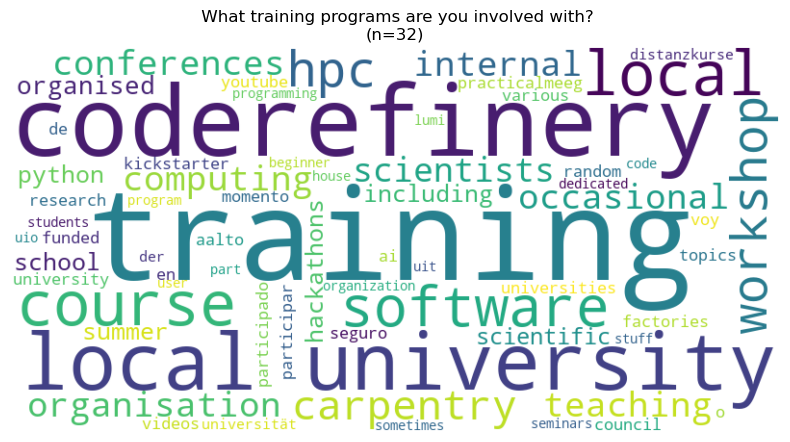

In [141]:
wordcloud_words('train3_0', cols, df_nord)



In [142]:
tell_me_more_count('ukrse3[1]_0', cols, df_nord)

Total responses: 63
 How did you learn the skills you need to become a Research Software Engineer / Research Software Developer? [Conferences]
ukrse3[1]_0
False    54
True      9
Name: count, dtype: int64


In [143]:
tell_me_more_count('ukrse3[2]_0', cols, df_nord)

Total responses: 63
 How did you learn the skills you need to become a Research Software Engineer / Research Software Developer? [Learned on-the-job]
ukrse3[2]_0
True     51
False    12
Name: count, dtype: int64


In [144]:
tell_me_more_count('ukrse3[3]_0', cols, df_nord)

Total responses: 63
 How did you learn the skills you need to become a Research Software Engineer / Research Software Developer? [Online courses]
ukrse3[3]_0
False    43
True     20
Name: count, dtype: int64


In [145]:
tell_me_more_count('ukrse3[4]_0', cols, df_nord)

Total responses: 63
 How did you learn the skills you need to become a Research Software Engineer / Research Software Developer? [Self-taught]
ukrse3[4]_0
True     40
False    23
Name: count, dtype: int64


In [146]:
tell_me_more_count('ukrse3[5]_0', cols, df_nord)

Total responses: 63
 How did you learn the skills you need to become a Research Software Engineer / Research Software Developer? [Summer schools or workshops]
ukrse3[5]_0
False    57
True      6
Name: count, dtype: int64


In [147]:
tell_me_more_count('ukrse3[6]_0', cols, df_nord)

Total responses: 63
 How did you learn the skills you need to become a Research Software Engineer / Research Software Developer? [University course or module]
ukrse3[6]_0
False    32
True     31
Name: count, dtype: int64


In [148]:
tell_me_more_count('org3nord[1]_0', cols, df_nord)

Total responses: 72
 How could Nordic-RSE or a potential Nordic research software institute foster community engagement and knowledge transfer? [Organisation of conferences, workshops and similar events]
org3nord[1]_0
True     61
False    11
Name: count, dtype: int64


In [149]:
tell_me_more_count('org3nord[2]_0', cols, df_nord)

Total responses: 72
 How could Nordic-RSE or a potential Nordic research software institute foster community engagement and knowledge transfer? [Running regular online talk-series]
org3nord[2]_0
False    49
True     23
Name: count, dtype: int64


In [150]:
tell_me_more_count('org3nord[3]_0', cols, df_nord)

Total responses: 72
 How could Nordic-RSE or a potential Nordic research software institute foster community engagement and knowledge transfer? [Organisation of online and/or in-person trainings]
org3nord[3]_0
False    37
True     35
Name: count, dtype: int64


In [151]:
tell_me_more_count('org3nord[4]_0', cols, df_nord)

Total responses: 72
 How could Nordic-RSE or a potential Nordic research software institute foster community engagement and knowledge transfer? [Hosting an easily searchable database of trainings available through other institutions]
org3nord[4]_0
False    45
True     27
Name: count, dtype: int64


In [152]:
tell_me_more_count('org3nord[5]_0', cols, df_nord)

Total responses: 72
 How could Nordic-RSE or a potential Nordic research software institute foster community engagement and knowledge transfer? [Compilation and development of freely available training materials (for teaching and self-studying)]
org3nord[5]_0
False    40
True     32
Name: count, dtype: int64


In [153]:
tell_me_more_count('org3nord[6]_0', cols, df_nord)

Total responses: 72
 How could Nordic-RSE or a potential Nordic research software institute foster community engagement and knowledge transfer? [Coordination of train-the-trainer programs (e.g. Carpentries) for Nordics]
org3nord[6]_0
False    48
True     24
Name: count, dtype: int64


In [154]:
tell_me_more_count('org4nord[1]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [In-house development of research software]
org4nord[1]_0
False    55
True     17
Name: count, dtype: int64


In [155]:
tell_me_more_count('org4nord[2]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [Temporary support of research software projects with manpower]
org4nord[2]_0
False    50
True     22
Name: count, dtype: int64


In [156]:
tell_me_more_count('org4nord[3]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [Maintenance of internationally relevant research software]
org4nord[3]_0
False    39
True     33
Name: count, dtype: int64


In [157]:
tell_me_more_count('org4nord[4]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [Consulting on research software development]
org4nord[4]_0
False    37
True     35
Name: count, dtype: int64


In [158]:
tell_me_more_count('org4nord[5]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [Development and dissemination of standards (e.g., for quality, metadata)]
org4nord[5]_0
True     39
False    33
Name: count, dtype: int64


In [159]:
tell_me_more_count('org4nord[6]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [Research on RSE topics]
org4nord[6]_0
False    43
True     29
Name: count, dtype: int64


In [160]:
tell_me_more_count('org4nord[7]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [Community engagement and trainings]
org4nord[7]_0
True     45
False    27
Name: count, dtype: int64


In [161]:
tell_me_more_count('org4nord[8]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [Advocating for research software towards politicians and decision makers]
org4nord[8]_0
True     47
False    25
Name: count, dtype: int64


In [162]:
tell_me_more_count('org4nord[9]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [Promotion of career paths in the RSE field]
org4nord[9]_0
True     48
False    24
Name: count, dtype: int64


In [163]:
tell_me_more_count('org4nord[10]_0', cols, df_nord)

Total responses: 72
 With Nordic-RSE we have an association dedicated to the community of Research Software Engineers in the Nordics. What tasks do you think should be undertaken by Nordic-RSE or a future Nordic institute for research software? [Offer funding for research software projects]
org4nord[10]_0
False    47
True     25
Name: count, dtype: int64


In [164]:
tell_me_more_count('rse1_0', cols, df_nord)

Total responses: 72
 Do you write software for academic research as part of your job?
rse1_0
True     66
False     6
Name: count, dtype: int64


In [165]:
tell_me_more_count('rse3_0', cols, df_nord)

Total responses: 66
 Who uses the code that you write? 
rse3_0
4                          17
3                          16
5 - Mostly other people    15
2                           8
1                           5
0 - Mostly me               5
Name: count, dtype: int64


In [166]:
pd.set_option('display.max_rows', None)
df_nord['train3_0'].dropna()

296       CodeRefinery, local training by my organisation
330     Training organised by my organisation, includi...
377     Python for Scientific Computing, PracticalMEEG...
388     CodeRefinery, local university training, AI fa...
405     de momento he participado (o voy a participar ...
407                          CodeRefinery, local training
408                   Internal training in various topics
415                                          CodeRefinery
967               CodeRefinery, local university training
1068          CodeRefinery, local university HPC training
1069                                         CodeRefinery
373     Local university training, workshops at confer...
543                                  Occasional workshops
544                             Local university training
768                          Distanzkurse der Universität
1081                            Local university training
1093                   Course in computing for scientists
1101          

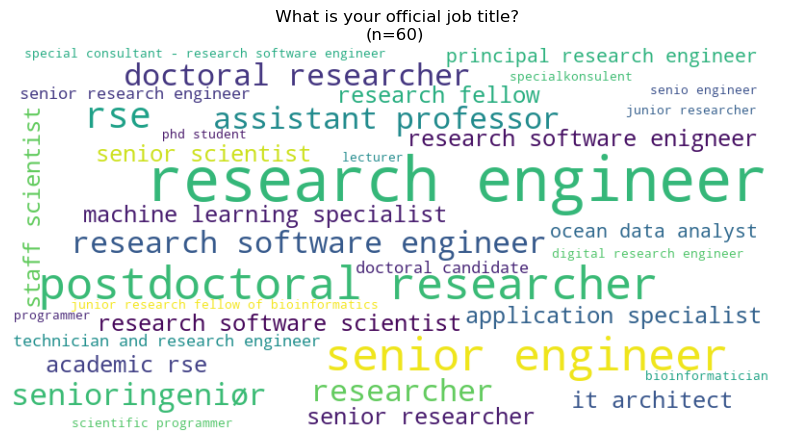

In [167]:
wordcloud('currentEmp5_0', cols, df_nord)



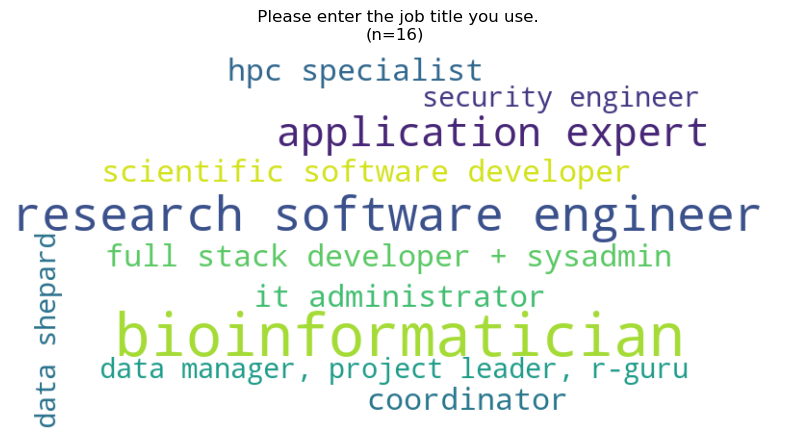

In [168]:
wordcloud('currentEmp60_0', cols, df_nord)

In [169]:
tell_me_more_count('currentWork2_0', cols, df_nord)

Total responses: 59
 Are you part of a dedicated research software group within your institution?
currentWork2_0
True     33
False    26
Name: count, dtype: int64


In [170]:
tell_me_more_count('fund3[1]_0', cols, df_nord)



Total responses: 63
 Which of the following sources are used to pay for your effort as a Research Software Engineer? [Institutional support (centrally funded)]
fund3[1]_0
True     43
False    20
Name: count, dtype: int64


In [171]:
tell_me_more_count('fund3[2]_0', cols, df_nord)

Total responses: 63
 Which of the following sources are used to pay for your effort as a Research Software Engineer? [Grants]
fund3[2]_0
True     40
False    23
Name: count, dtype: int64


In [172]:
tell_me_more_count('fund3[3]_0', cols, df_nord)

Total responses: 63
 Which of the following sources are used to pay for your effort as a Research Software Engineer? [I volunteer my time]
fund3[3]_0
False    56
True      7
Name: count, dtype: int64


In [173]:
tell_me_more_count('fund3[4]_0', cols, df_nord)

Total responses: 63
 Which of the following sources are used to pay for your effort as a Research Software Engineer? [Industry support]
fund3[4]_0
False    63
Name: count, dtype: int64


In [174]:
tell_me_more_count('fund3[5]_0', cols, df_nord)

Total responses: 63
 Which of the following sources are used to pay for your effort as a Research Software Engineer? [Consulting &amp; services]
fund3[5]_0
False    54
True      9
Name: count, dtype: int64


In [175]:
tell_me_more_count('fund3[6]_0', cols, df_nord)

Total responses: 63
 Which of the following sources are used to pay for your effort as a Research Software Engineer? [Foundations &amp; consortiums]
fund3[6]_0
False    59
True      4
Name: count, dtype: int64


In [176]:
tell_me_more_count('fund3[7]_0', cols, df_nord)


Total responses: 63
 Which of the following sources are used to pay for your effort as a Research Software Engineer? [Venture Capital]
fund3[7]_0
False    63
Name: count, dtype: int64


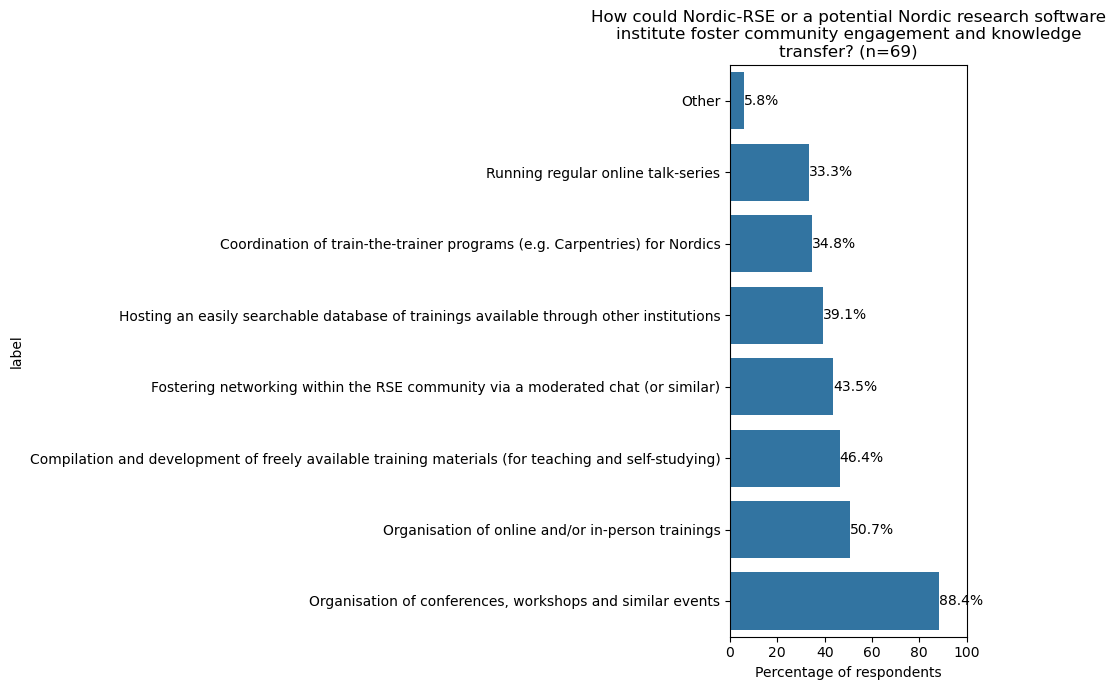

In [177]:
plot_multiselect('org3nord', cols, df_nord)

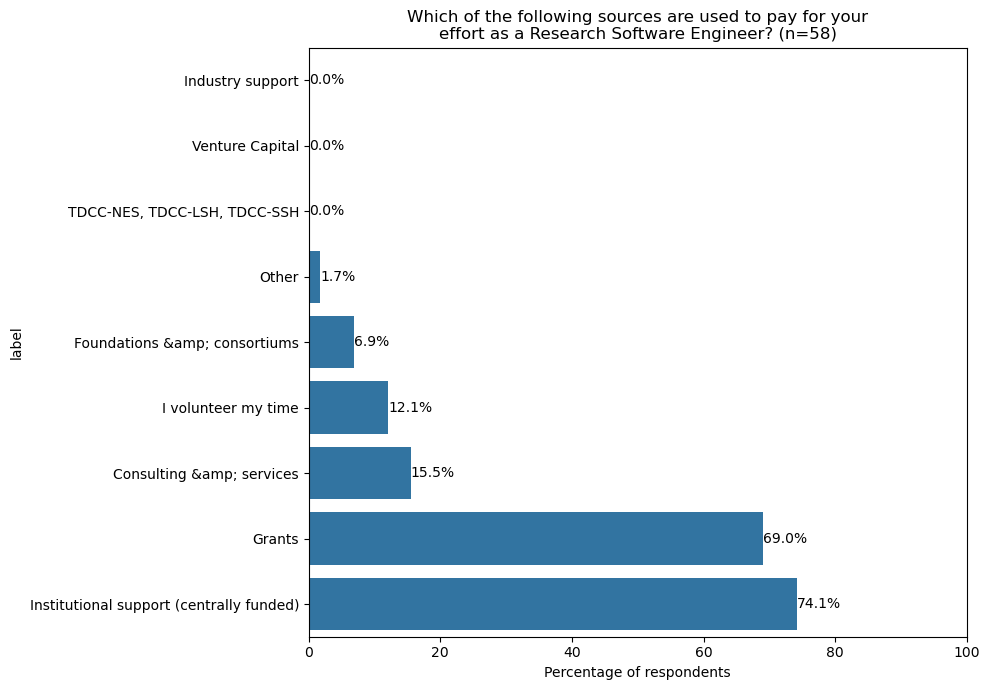

In [178]:
plot_multiselect('fund3', cols, df_nord)

In [179]:
# get all matching columns for a prefix
prefix = 'org3nord'
matching_cols = [c for c in df_nord.columns if c.startswith(prefix) and 'other' not in c]
df_nord[matching_cols].sum(axis=1).value_counts().sort_index()


0     3
1     5
2    19
3    14
4    18
5     6
6     4
7     3
Name: count, dtype: int64

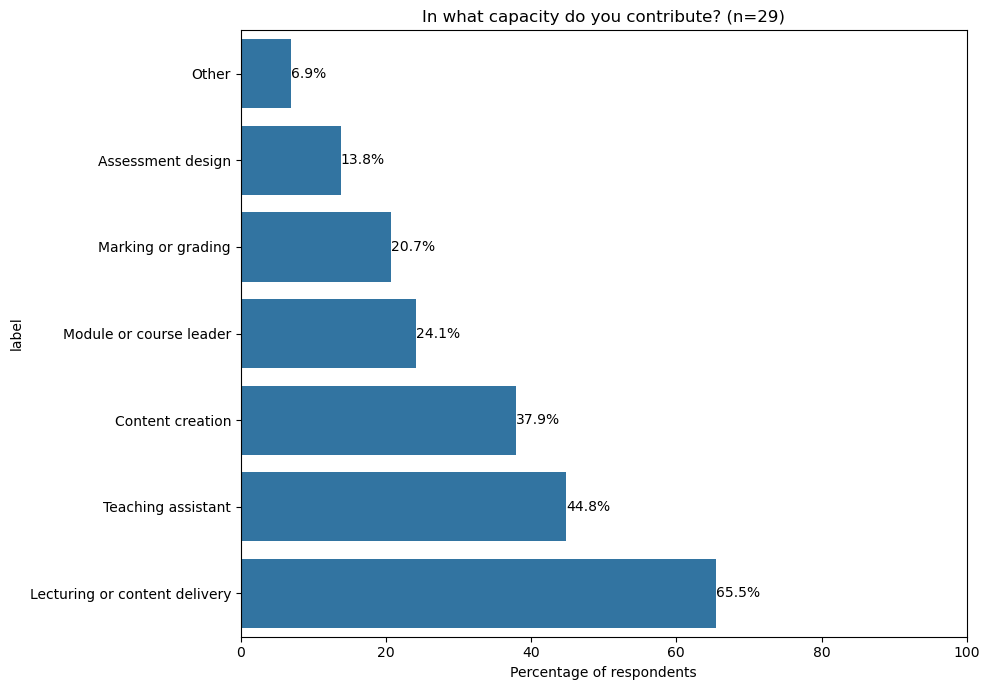

In [180]:
plot_multiselect('train5', cols, df_nord)

In [181]:
# get all matching columns for a prefix
prefix = 'train5'
matching_cols = [c for c in df_nord.columns if c.startswith(prefix) and 'other' not in c]
df_nord[matching_cols].sum(axis=1).value_counts().sort_index()

0    43
1    12
2     9
3     4
4     2
5     2
Name: count, dtype: int64

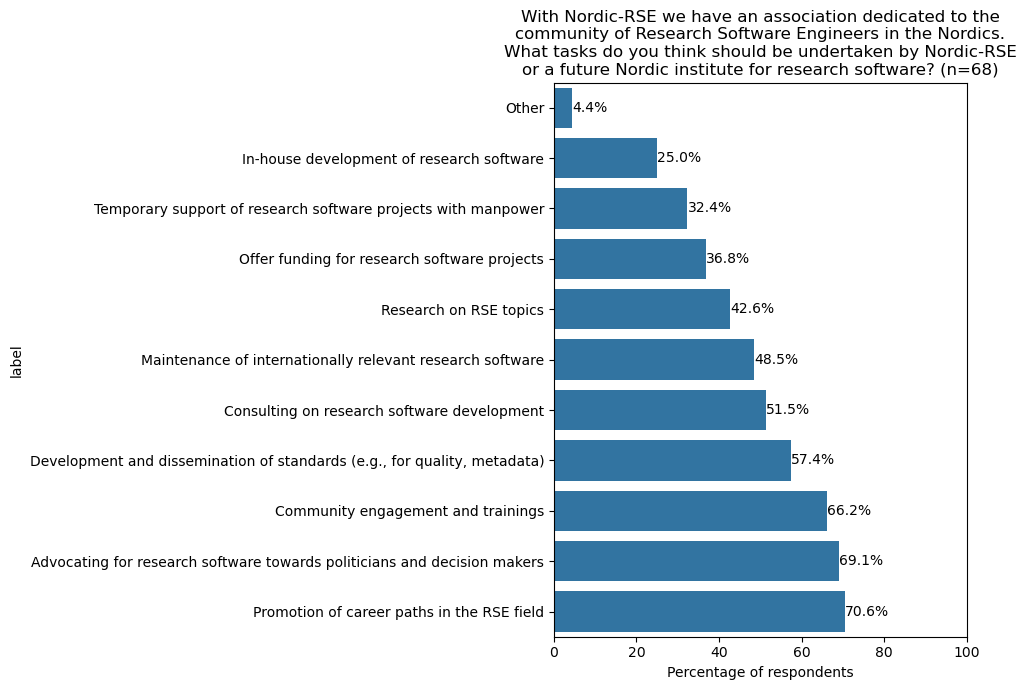

In [182]:
plot_multiselect('org4nord', cols, df_nord)

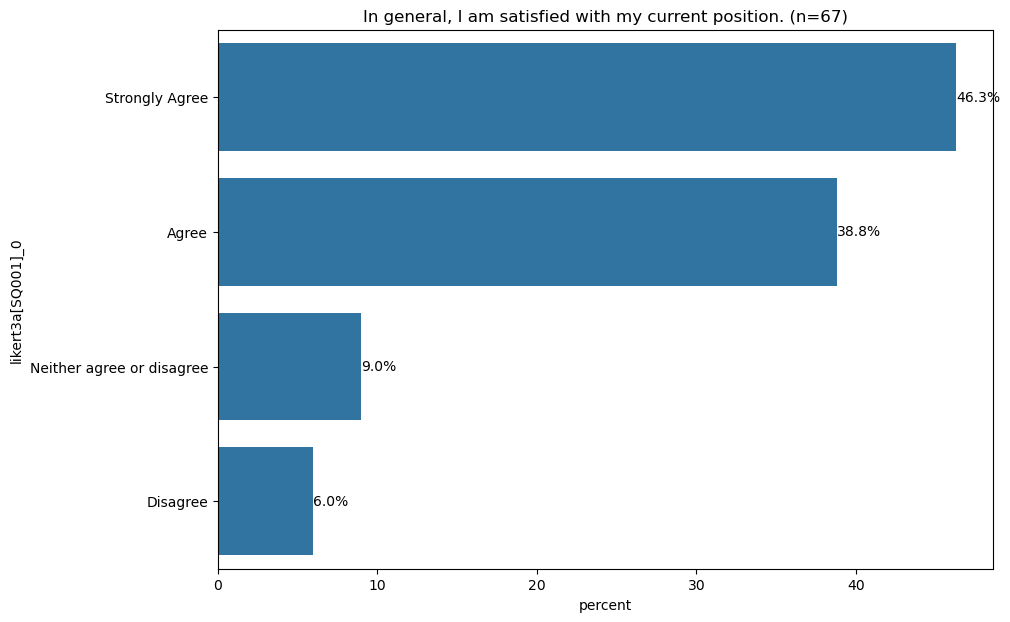

0

In [183]:
plot_barplot_percentage(df_nord,'likert3a[SQ001]_0', cols)


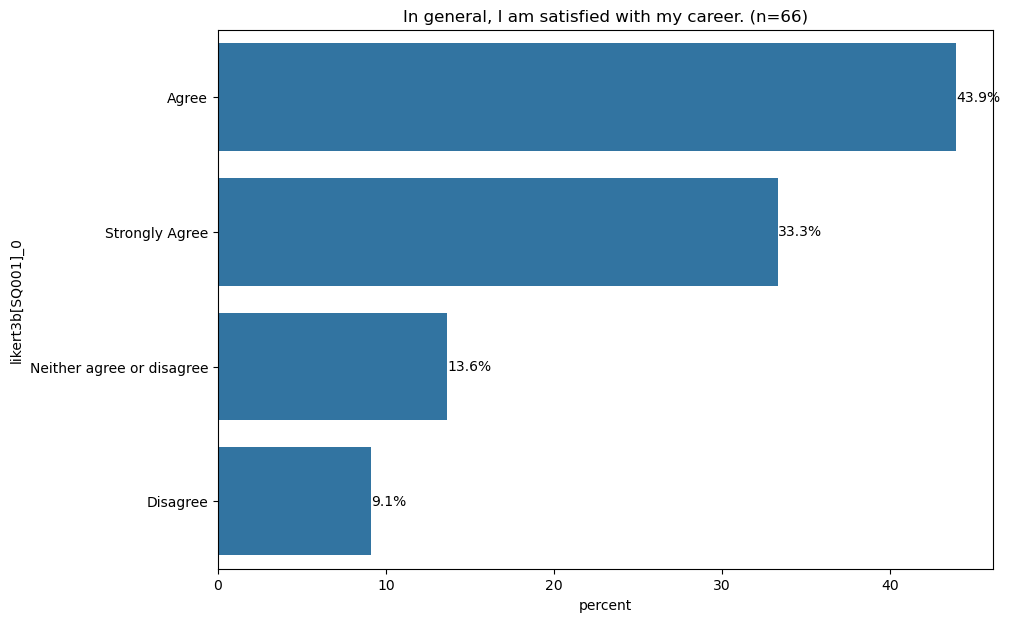

0

In [184]:
plot_barplot_percentage(df_nord, 'likert3b[SQ001]_0', cols)

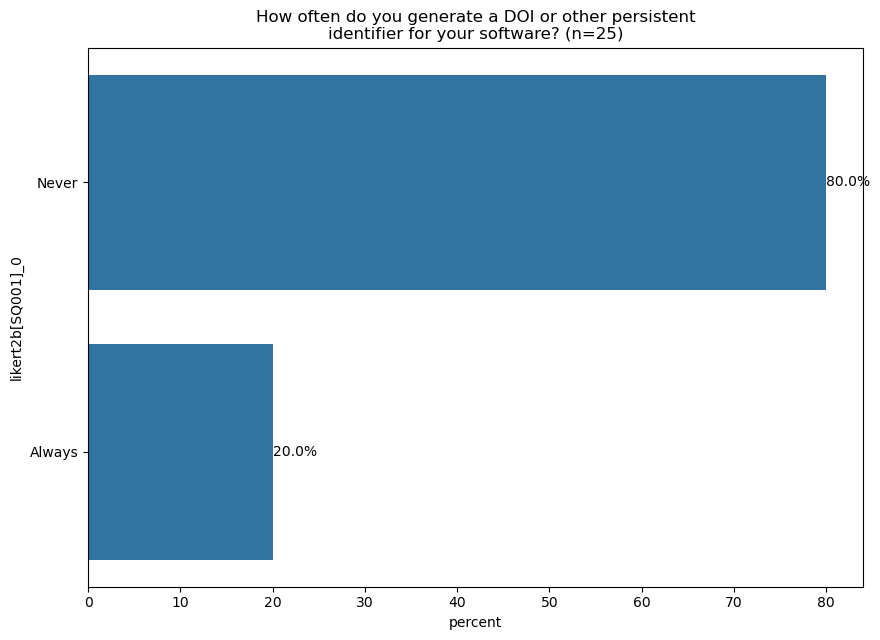

0

In [185]:
plot_barplot_percentage(df_nord, 'likert2b[SQ001]_0', cols)

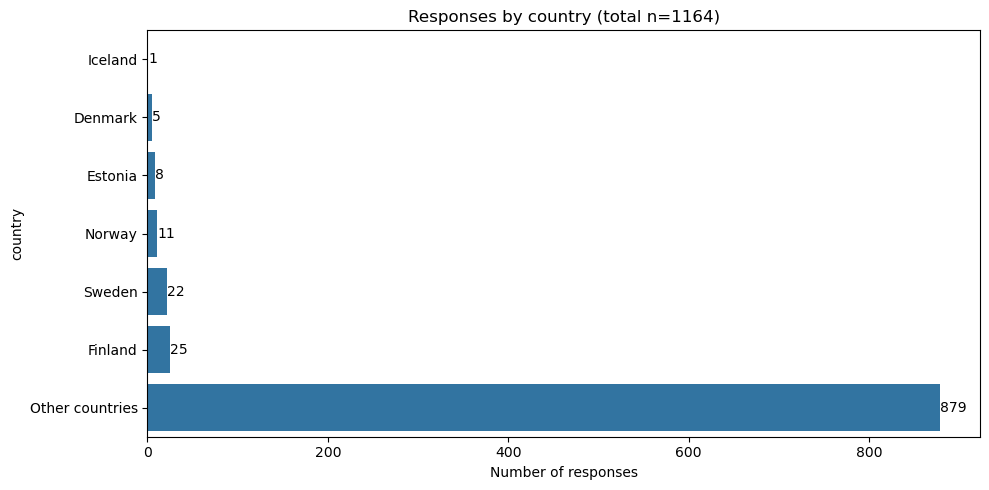

In [186]:
nordics = ['Finland', 'Norway', 'Sweden', 'Denmark', 'Iceland', 'Estonia']

counts = df['socio1_0'].value_counts()
nordic_counts = counts[counts.index.isin(nordics)]
other_count = counts[~counts.index.isin(nordics)].sum()

plot_df = pd.concat([nordic_counts, pd.Series({'Other countries': other_count})]).reset_index()
plot_df.columns = ['country', 'count']
plot_df = plot_df.sort_values('count')

plt.figure(figsize=(10, 5))
g = sns.barplot(data=plot_df, x='count', y='country')
for container in g.containers:
    g.bar_label(container)
plt.xlabel('Number of responses')
plt.title(f'Responses by country (total n={len(df)})')
plt.tight_layout()
plt.show()

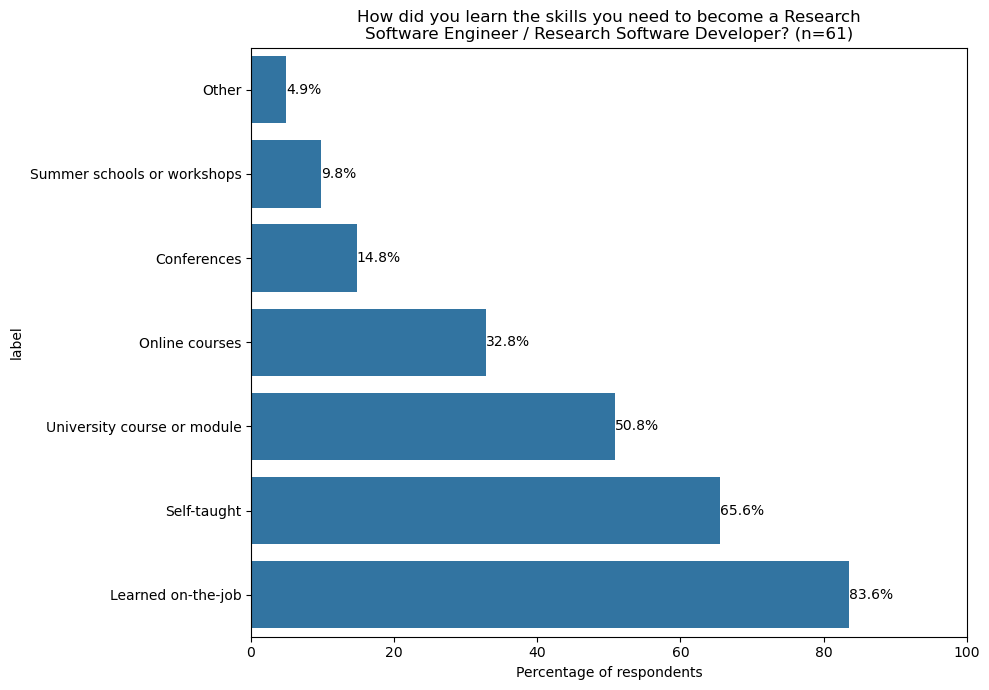

In [187]:
plot_multiselect('ukrse3', cols, df_nord)